# APT Multi-Factor Model: Credicorp Returns

**Objective:** Estimate how local market returns, copper prices, and the global financial sector explain Credicorp Ltd. (BAP) monthly log-returns.

**Model:**  
$$R_{Credicorp,t} = \beta_0 + \beta_1 R_{Peru,t} + \beta_2 R_{Cobre,t} + \beta_3 R_{GlobalFinance,t} + \varepsilon_t$$

**Framework:** Arbitrage Pricing Theory (Ross, 1976) — asset returns are driven by multiple systematic risk factors.

---
## 1. Data Acquisition

Download monthly close prices via `yfinance`, compute log-returns, and persist both raw prices and returns to CSV.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
TICKERS = {
    'Credicorp': 'BAP',
    'Peru_Mercado': 'EPU',
    'Precio_cobre': 'HG=F',
    'ETF_XLF': 'XLF',
}
START = '2020-01-01'
END = '2026-05-31'

In [3]:
def download_prices(tickers: dict, start: str, end: str) -> pd.DataFrame:
    """Download monthly close prices for given tickers."""
    prices = pd.DataFrame()
    for name, ticker in tickers.items():
        data = yf.download(ticker, start=start, end=end, interval='1d',
                           auto_adjust=True, progress=False)
        monthly = data['Close'].resample('ME').last()
        monthly.index = monthly.index.to_period('M')
        prices[name] = monthly
    return prices.dropna()


def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Convert price levels to log-returns (dropping first NaN row)."""
    return np.log(prices / prices.shift(1)).dropna()

In [4]:
prices = download_prices(TICKERS, START, END)
returns = compute_log_returns(prices)
returns.columns = ['R_Credicorp', 'R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']

prices.to_csv('precios_mensuales.csv')
returns.to_csv('base_datos_econometria.csv')

print(f'Observations: {len(returns)}')
print(returns.head().round(4))

Observations: 76
         R_Credicorp  R_Peru_Mercado  Precio_cobre  ETF_XLF
Date                                                       
2020-02      -0.1307         -0.0975        0.0103  -0.1193
2020-03      -0.2367         -0.3027       -0.1280  -0.2362
2020-04       0.1763          0.0910        0.0496   0.0904
2020-05      -0.0781          0.0769        0.0303   0.0268
2020-06      -0.0306          0.0572        0.1118  -0.0052


---
## 2. Exploratory Data Analysis

Scatter plots of Credicorp returns against each factor, with OLS trend lines.

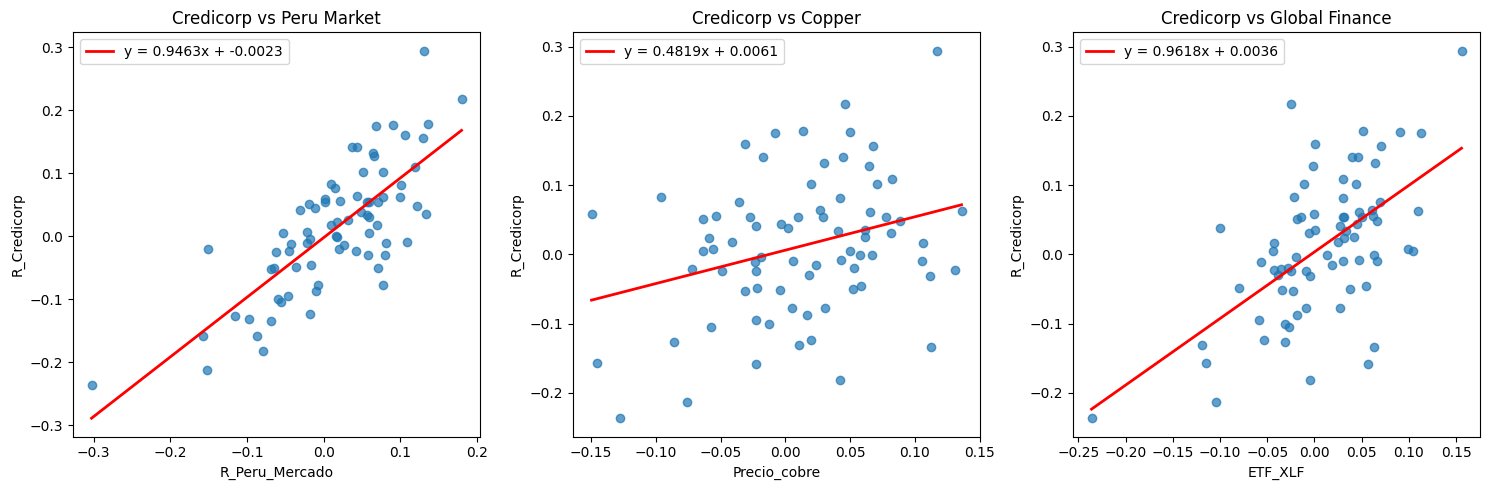

In [5]:
def scatter_with_trend(ax: plt.Axes, x: pd.Series, y: pd.Series,
                       xlabel: str, title: str) -> None:
    """Scatter plot with linear trend line."""
    ax.scatter(x, y, alpha=0.7)
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    order = np.argsort(x)
    ax.plot(x.iloc[order], trend(x.iloc[order]), 'r-', lw=2,
            label=f'y = {coef[0]:.4f}x + {coef[1]:.4f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('R_Credicorp')
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scatter_with_trend(axes[0], returns['R_Peru_Mercado'], returns['R_Credicorp'],
                   'R_Peru_Mercado', 'Credicorp vs Peru Market')
scatter_with_trend(axes[1], returns['Precio_cobre'], returns['R_Credicorp'],
                   'Precio_cobre', 'Credicorp vs Copper')
scatter_with_trend(axes[2], returns['ETF_XLF'], returns['R_Credicorp'],
                   'ETF_XLF', 'Credicorp vs Global Finance')
plt.tight_layout()
plt.show()

---
## 3. OLS Regression — Multi-Factor Model

Estimate the APT model and run standard econometric diagnostics.

In [6]:
def fit_ols(returns: pd.DataFrame) -> sm.regression.linear_model.RegressionResultsWrapper:
    """Fit OLS: R_Credicorp ~ R_Peru_Mercado + Precio_cobre + ETF_XLF + const."""
    y = returns['R_Credicorp']
    X = returns[['R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']]
    X = sm.add_constant(X)
    return sm.OLS(y, X).fit()


model = fit_ols(returns)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            R_Credicorp   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     51.53
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           6.75e-18
Time:                        15:49:10   Log-Likelihood:                 110.99
No. Observations:                  76   AIC:                            -214.0
Df Residuals:                      72   BIC:                            -204.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0003      0.007     -0.

In [7]:
def diagnostic_report(model) -> None:
    """Print normality, autocorrelation, and heteroscedasticity tests."""
    resid = model.resid
    sep = '=' * 60

    # Jarque-Bera (normality)
    jb_stat, jb_p = stats.jarque_bera(resid)
    print(sep)
    print('JARQUE-BERA (Normality)')
    print(sep)
    print(f'Statistic: {jb_stat:.4f}  p-value: {jb_p:.4f}')
    print('Residuals are normal' if jb_p > 0.05 else 'Residuals are NOT normal')

    # Durbin-Watson (autocorrelation)
    dw = sm.stats.stattools.durbin_watson(resid)
    print(f'\nDurbin-Watson: {dw:.4f}')
    print('No severe autocorrelation' if 1.5 <= dw <= 2.5 else 'Possible autocorrelation')

    # Breusch-Godfrey (higher-order autocorrelation)
    bg = acorr_breusch_godfrey(model, nlags=2)
    print(f'Breusch-Godfrey p-value: {bg[1]:.4f}')
    print('No autocorrelation' if bg[1] > 0.05 else 'Autocorrelation detected')

    # White (heteroscedasticity)
    white = het_white(resid, model.model.exog)
    print(f'White p-value: {white[1]:.4f}')
    print('Homoscedastic' if white[1] > 0.05 else 'Heteroscedasticity detected')
    print(sep)


diagnostic_report(model)

JARQUE-BERA (Normality)
Statistic: 0.4914  p-value: 0.7821
Residuals are normal

Durbin-Watson: 2.3391
No severe autocorrelation
Breusch-Godfrey p-value: 0.2323
No autocorrelation
White p-value: 0.0655
Homoscedastic


---
## 4. Cross-Validation

5-fold cross-validated R² to assess out-of-sample predictive power.

In [8]:
X = returns[['R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']].values
y = returns['R_Credicorp'].values

lr = LinearRegression()
scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print('Fold R² scores:', np.round(scores, 4))
print(f'Mean CV R²: {scores.mean():.4f}')

Fold R² scores: [0.604  0.8214 0.6228 0.435  0.4055]
Mean CV R²: 0.5777


---
## 5. Summary

| Factor | Coefficient | p-value | Interpretation |
|---|---|---|---|
| Peru Market | — | — | Market beta — dominant factor |
| Copper Price | — | — | Commodity channel for an emerging-market bank |
| Global Finance | — | — | International financial contagion/liquidity |

Check the regression output above for exact values. The diagnostics confirm whether OLS assumptions hold (normal residuals, no autocorrelation, homoscedasticity).